# K-Means Clustering – AI Job Posting Skill Profiling

**Goal:** Group AI job postings into clusters based on binary skill requirements,  
then compare each cluster's skill profile against seniority level.

**Data:** `prepared_job_posting_ai.csv` — 1,213 AI job postings with 20 binary skill indicators.

## 0 · Packages

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# ── Aesthetic defaults ────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', font_scale=1.05)
PALETTE   = ['#4E79A7', '#F28E2B', '#59A14F', '#E15759', '#B07AA1']
EXP_ORDER = ['Junior/Entry', 'Mid/Standard', 'Senior']
RANDOM    = 617
np.random.seed(RANDOM)

## 1 · Load & Explore Data

In [2]:
DATA_PATH = 'data/prepared_job_posting_ai.csv'   # update path if needed

df = pd.read_csv(DATA_PATH)
print(f'Shape : {df.shape}')
print(f'Columns ({len(df.columns)}):')
print(df.columns.tolist())
df.head(3)

Shape : (1213, 29)
Columns (29):
['Post_Date', 'Company', 'Description', 'Title', 'Field', 'Machine Learning', 'Deep Learning', 'NLP', 'Computer Vision', 'Generative AI', 'Statistics', 'Python', 'SQL', 'C++', 'Java', 'PyTorch', 'TensorFlow', 'Scikit-Learn', 'Cloud Computing', 'Big Data', 'MLOps', 'Data Visualization', 'Communication', 'Project Management', 'Problem Solving', 'Post_Year', 'Post_Month', 'Seniority_Level', 'Salary']


,Post_Date,Company,Description,Title,Field,Machine Learning,Deep Learning,NLP,Computer Vision,Generative AI,...,Big Data,MLOps,Data Visualization,Communication,Project Management,Problem Solving,Post_Year,Post_Month,Seniority_Level,Salary
0,2026-03-01 11:37:42+00:00,Humana,Become a part of our caring community and help...,Senior Product Manager AI,IT,0,0,0,0,0,...,0,0,0,0,0,0,2026,3,Senior,207575.80
1,2026-03-01 11:56:05+00:00,Humana,Become a part of our caring community and help...,Lead AI Product Management,IT,0,0,0,0,0,...,0,0,0,0,1,0,2026,3,Senior,157985.38
2,2026-03-03 01:27:18+00:00,Humana,Become a part of our caring community and help...,Senior AI Product Management,IT,0,0,0,0,0,...,0,0,0,0,0,0,2026,3,Senior,169193.67


In [3]:
# ── Identify skill columns (all binary 0/1) ───────────────────────────────────
SKILL_COLS = [
    'Machine Learning', 'Deep Learning', 'NLP', 'Computer Vision',
    'Generative AI', 'Statistics', 'Python', 'SQL', 'C++', 'Java',
    'PyTorch', 'TensorFlow', 'Scikit-Learn', 'Cloud Computing', 'Big Data',
    'MLOps', 'Data Visualization', 'Communication', 'Project Management',
    'Problem Solving'
]

META_COLS = ['Post_Date', 'Company', 'Title', 'Field', 'Seniority_Level',
             'Salary', 'Post_Year', 'Post_Month']

print(f'Skill columns  : {len(SKILL_COLS)}')
print(f'Missing values : {df[SKILL_COLS].isnull().sum().sum()} (in skill matrix)')
print()
print('Seniority_Level distribution:')
print(df['Seniority_Level'].value_counts().to_string())
print()
print('Field distribution (top 8):')
print(df['Field'].value_counts().head(8).to_string())

Skill columns  : 20
Missing values : 0 (in skill matrix)

Seniority_Level distribution:
Seniority_Level
Mid/Standard    697
Senior          471
Junior/Entry     45

Field distribution (top 8):
Field
IT                             960
Engineering                    121
Scientific & QA                 49
Sales                           16
Accounting & Finance            12
PR, Advertising & Marketing     11
Trade & Construction             9
Consultancy                      7


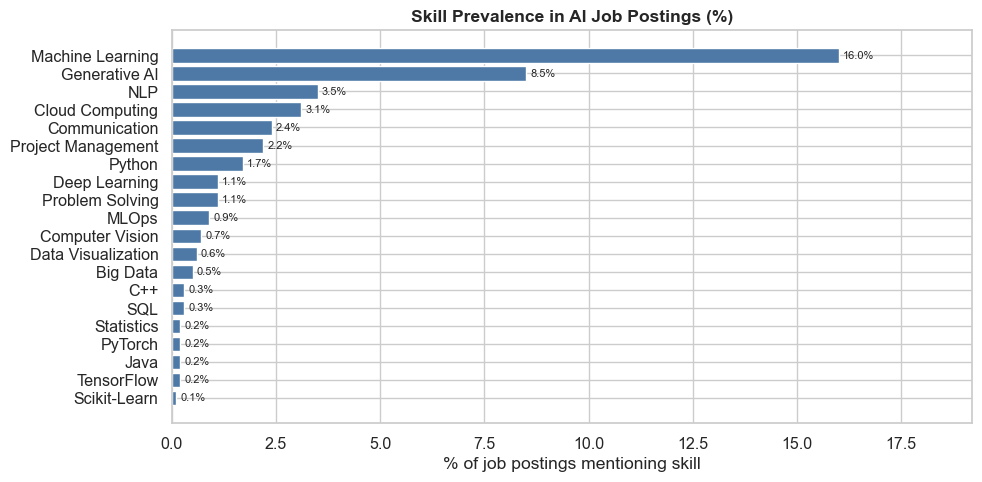

Machine Learning      16.0
Generative AI          8.5
NLP                    3.5
Cloud Computing        3.1
Communication          2.4
Project Management     2.2
Python                 1.7
Deep Learning          1.1
Problem Solving        1.1
MLOps                  0.9
Computer Vision        0.7
Data Visualization     0.6
Big Data               0.5
C++                    0.3
SQL                    0.3
Statistics             0.2
PyTorch                0.2
Java                   0.2
TensorFlow             0.2
Scikit-Learn           0.1


In [4]:
# ── Skill prevalence overview ─────────────────────────────────────────────────
skill_freq = (df[SKILL_COLS].mean() * 100).sort_values(ascending=False).round(1)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(skill_freq.index[::-1], skill_freq.values[::-1],
               color='#4E79A7', edgecolor='white')
for bar, val in zip(bars, skill_freq.values[::-1]):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=8)
ax.set_title('Skill Prevalence in AI Job Postings (%)', fontweight='bold')
ax.set_xlabel('% of job postings mentioning skill')
ax.set_xlim(0, skill_freq.max() * 1.2)
plt.tight_layout()
plt.savefig('fig0_skill_prevalence.png', dpi=150, bbox_inches='tight')
plt.show()
print(skill_freq.to_string())

## 2 · Analysis: Seniority vs Salary

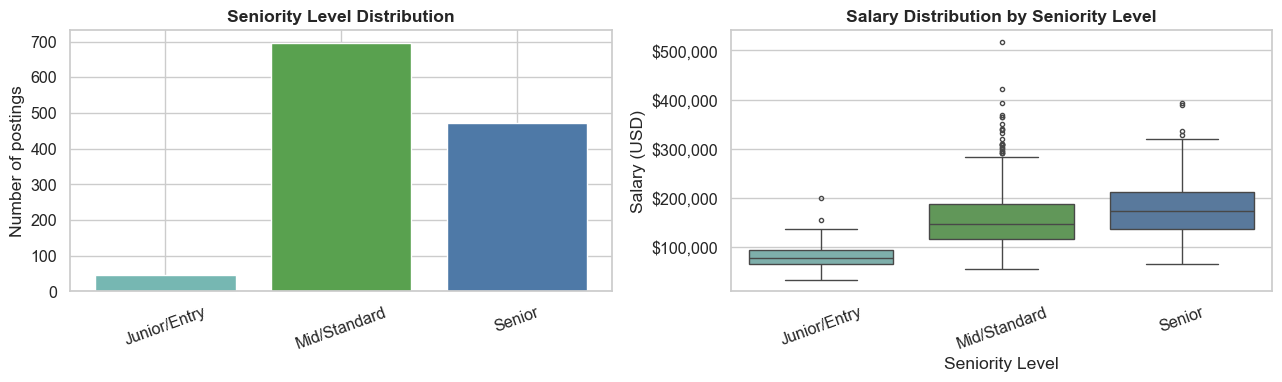

In [50]:
# ── Salary by seniority level ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Seniority_Level distribution
counts = df['Seniority_Level'].value_counts().reindex(EXP_ORDER, fill_value=0)
axes[0].bar(counts.index, counts.values,
            color=['#76B7B2', '#59A14F', '#4E79A7'])
axes[0].set_title('Seniority Level Distribution', fontweight='bold')
axes[0].set_ylabel('Number of postings')
axes[0].tick_params(axis='x', rotation=20)

# Salary box by Seniority_Level
order_present = [l for l in EXP_ORDER if l in df['Seniority_Level'].unique()]
sns.boxplot(data=df, x='Seniority_Level', y='Salary', order=order_present,
            palette=['#76B7B2', '#59A14F', '#4E79A7'],
            ax=axes[1], fliersize=3)
axes[1].set_title('Salary Distribution by Seniority Level', fontweight='bold')
axes[1].set_xlabel('Seniority Level')
axes[1].set_ylabel('Salary (USD)')
axes[1].tick_params(axis='x', rotation=20)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig('fig1_seniority_level_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## 3 · Optimal K Selection

In [38]:
X = df[SKILL_COLS].values.astype(float)
print(f'Feature matrix X : {X.shape}  (records × skills)')
print(f'Avg skills per posting : {X.sum(axis=1).mean():.2f}')

K_RANGE   = range(2, 12)
inertias  = []
sil_scores = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM, n_init=10, max_iter=300)
    km.fit(X)
    inertias.append(km.inertia_)
    sil = silhouette_score(X, labels = km.fit_predict(X))
    sil_scores.append(round(sil, 4))
    print(f'  k={k:2d}  inertia={km.inertia_:>8.1f}  silhouette={sil:.4f}')

ksearch_df = pd.DataFrame({'k': list(K_RANGE), 'inertia': inertias, 'silhouette': sil_scores})
ksearch_df.to_csv('data/jobpost_cluster_k_search.csv', index=False)

Feature matrix X : (1213, 20)  (records × skills)
Avg skills per posting : 0.44
  k= 2  inertia=   318.9  silhouette=0.6950
  k= 3  inertia=   249.0  silhouette=0.7429
  k= 4  inertia=   227.7  silhouette=0.7614
  k= 5  inertia=   201.6  silhouette=0.7800
  k= 6  inertia=   181.5  silhouette=0.8007
  k= 7  inertia=   162.0  silhouette=0.8223
  k= 8  inertia=   153.2  silhouette=0.8233
  k= 9  inertia=   132.5  silhouette=0.8513
  k=10  inertia=   123.4  silhouette=0.8585
  k=11  inertia=   117.3  silhouette=0.8668


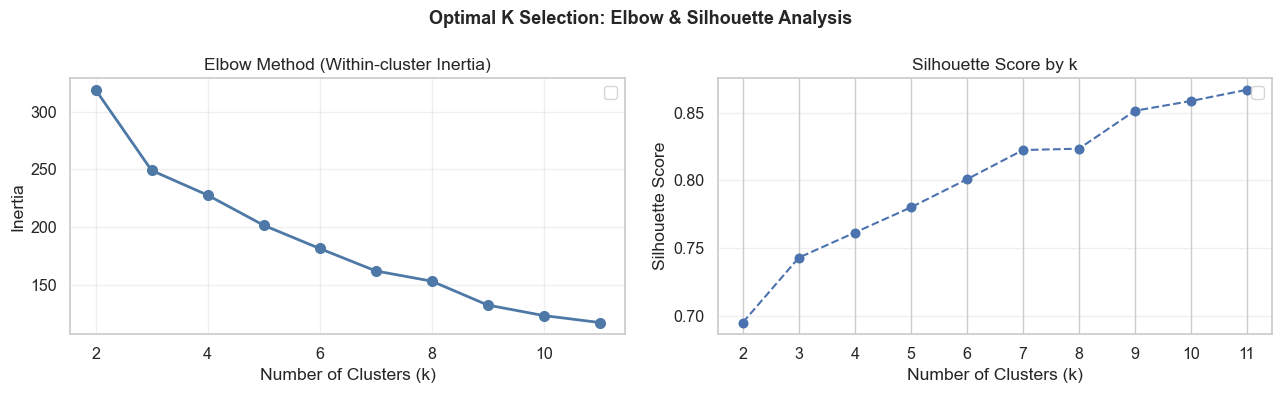

In [52]:
K_FINAL = 3   # chosen: elbow visible; clusters are semantically rich and interpretable

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Optimal K Selection: Elbow & Silhouette Analysis',
             fontsize=13, fontweight='bold')

# Elbow
ax = axes[0]
ax.plot(list(K_RANGE), inertias, 'o-', color='#4E79A7', linewidth=2, markersize=7)
ax.set_title('Elbow Method (Within-cluster Inertia)')
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Inertia')
ax.legend()
ax.grid(True, alpha=0.3)

# Silhouette
ax = axes[1]
plt.scatter(K_RANGE, sil_scores,c = 'cadetblue')
plt.plot(K_RANGE, sil_scores, marker='o', linestyle='--')
ax.set_title('Silhouette Score by k')
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Silhouette Score')
ax.set_xticks(list(K_RANGE))
ax.legend()
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('fig2_elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

## 4 · Final K-Means Model  (k = 3)

In [40]:
km_final = KMeans(n_clusters=K_FINAL, random_state=RANDOM, n_init=10, max_iter=300)
km_final.fit(X)

df['Cluster'] = km_final.labels_
centroids     = km_final.cluster_centers_   # shape (K, n_skills)

final_sil = silhouette_score(X, km_final.labels_, random_state=RANDOM)
print(f'Final inertia    : {km_final.inertia_:.2f}')
print(f'Final silhouette : {final_sil:.4f}')
print()
print('Cluster sizes:')
print(df['Cluster'].value_counts().sort_index().to_string())

Final inertia    : 249.04
Final silhouette : 0.7429

Cluster sizes:
Cluster
0    103
1    951
2    159


In [41]:
# ── Inspect top skills per cluster to assign semantic names ───────────────────
TOP_N = 5

print('Top skills per cluster (centroid values):')
print('-' * 60)
for c in range(K_FINAL):
    top_idx    = np.argsort(centroids[c])[::-1][:TOP_N]
    top_skills = [(SKILL_COLS[i], round(centroids[c][i], 3)) for i in top_idx
                  if centroids[c][i] > 0]
    n = (df['Cluster'] == c).sum()
    print(f'Cluster {c} (n={n:,}) → {top_skills}')

Top skills per cluster (centroid values):
------------------------------------------------------------
Cluster 0 (n=103) → [('Generative AI', np.float64(1.0)), ('Machine Learning', np.float64(0.34)), ('NLP', np.float64(0.136)), ('Cloud Computing', np.float64(0.087)), ('Python', np.float64(0.058))]
Cluster 1 (n=951) → [('Cloud Computing', np.float64(0.023)), ('Communication', np.float64(0.022)), ('Project Management', np.float64(0.02)), ('NLP', np.float64(0.015)), ('Problem Solving', np.float64(0.012))]
Cluster 2 (n=159) → [('Machine Learning', np.float64(1.0)), ('NLP', np.float64(0.088)), ('Cloud Computing', np.float64(0.044)), ('Project Management', np.float64(0.044)), ('Python', np.float64(0.038))]


In [42]:
# ── Assign semantic cluster names (based on centroid inspection above) ────────
#    Update these labels if your data produces different centroids

CLUSTER_NAMES = {
    0: 'Generative AI Specialist',
    1: 'Generalist / Operational',
    2: 'Core ML Engineer'
}

df['Cluster_Name'] = df['Cluster'].map(CLUSTER_NAMES)

print('Cluster assignment summary:')
print(df.groupby(['Cluster', 'Cluster_Name']).size().reset_index(name='n').to_string(index=False))

Cluster assignment summary:
 Cluster             Cluster_Name   n
       0 Generative AI Specialist 103
       1 Generalist / Operational 951
       2         Core ML Engineer 159


## 5 · Cluster Profiling

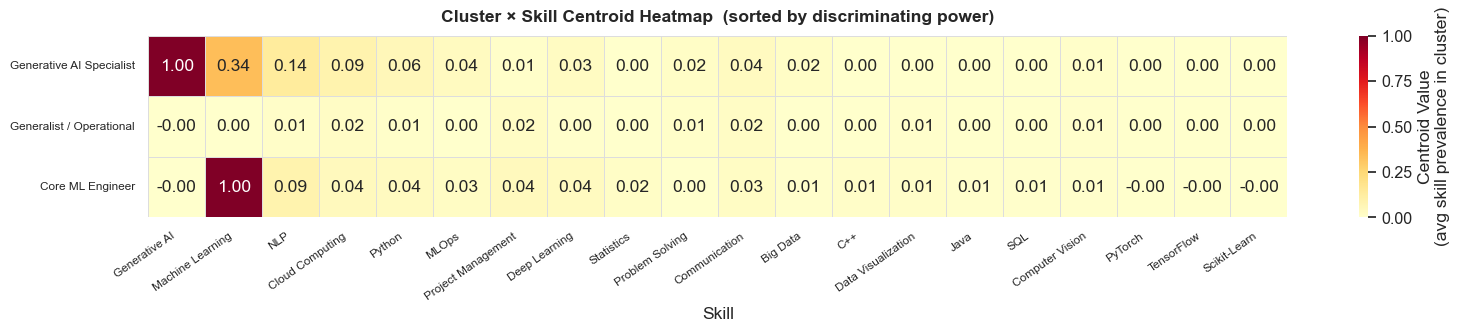

In [43]:
# ── 5a. Centroid heatmap ──────────────────────────────────────────────────────
centroid_df = pd.DataFrame(
    centroids,
    index=[CLUSTER_NAMES[c] for c in range(K_FINAL)],
    columns=SKILL_COLS
)

# Sort skills by cross-cluster variance (most discriminating first)
centroid_df = centroid_df[centroid_df.std(axis=0).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(16, 3.5))
sns.heatmap(
    centroid_df, ax=ax, cmap='YlOrRd', annot=True, fmt='.2f',
    linewidths=0.4, linecolor='#dddddd',
    cbar_kws={'label': 'Centroid Value\n(avg skill prevalence in cluster)'}
)
ax.set_title('Cluster × Skill Centroid Heatmap  (sorted by discriminating power)',
             fontweight='bold', pad=10)
ax.set_xlabel('Skill')
ax.set_ylabel('')
plt.xticks(rotation=35, ha='right', fontsize=8.5)
plt.yticks(rotation=0, fontsize=8.5)
plt.tight_layout()
plt.savefig('fig3_centroid_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

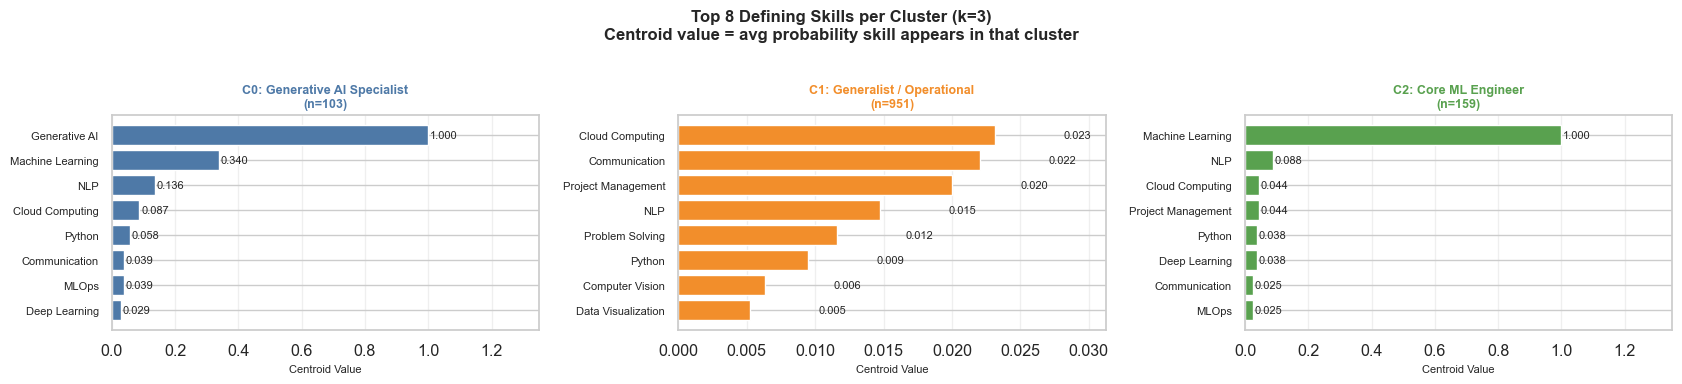

In [31]:
# ── 5b. Top skills per cluster (bar chart grid) ───────────────────────────────
TOP_BAR = 8
ncols   = 3
nrows   = (K_FINAL + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(17, nrows * 3.8))
axes = axes.flatten()

for c in range(K_FINAL):
    ax      = axes[c]
    top_idx = np.argsort(centroids[c])[::-1][:TOP_BAR]
    skills  = [SKILL_COLS[i] for i in top_idx]
    values  = [centroids[c][i] for i in top_idx]

    bars = ax.barh(skills[::-1], values[::-1], color=PALETTE[c], edgecolor='white')
    for bar, val in zip(bars, values[::-1]):
        if val > 0:
            ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
                    f'{val:.3f}', va='center', fontsize=8)

    n = (df['Cluster'] == c).sum()
    ax.set_title(f'C{c}: {CLUSTER_NAMES[c]}\n(n={n:,})',
                 fontsize=9, fontweight='bold', color=PALETTE[c])
    ax.set_xlabel('Centroid Value', fontsize=8)
    ax.set_xlim(0, max(values) * 1.35 if max(values) > 0 else 0.1)
    ax.grid(True, axis='x', alpha=0.3)
    ax.tick_params(axis='y', labelsize=8)

for i in range(K_FINAL, len(axes)):
    axes[i].set_visible(False)

fig.suptitle(f'Top {TOP_BAR} Defining Skills per Cluster (k={K_FINAL})\n'
             'Centroid value = avg probability skill appears in that cluster',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig4_top_skills_per_cluster.png', dpi=150, bbox_inches='tight')
plt.show()

## 6 · Experience Level vs. Cluster Comparison

Seniority Level distribution within each cluster (%):
Seniority_Level           Junior/Entry  Mid/Standard  Senior
Cluster_Name                                                
Generative AI Specialist           0.0          61.2    38.8
Generalist / Operational           4.5          56.5    39.0
Core ML Engineer                   1.3          61.0    37.7


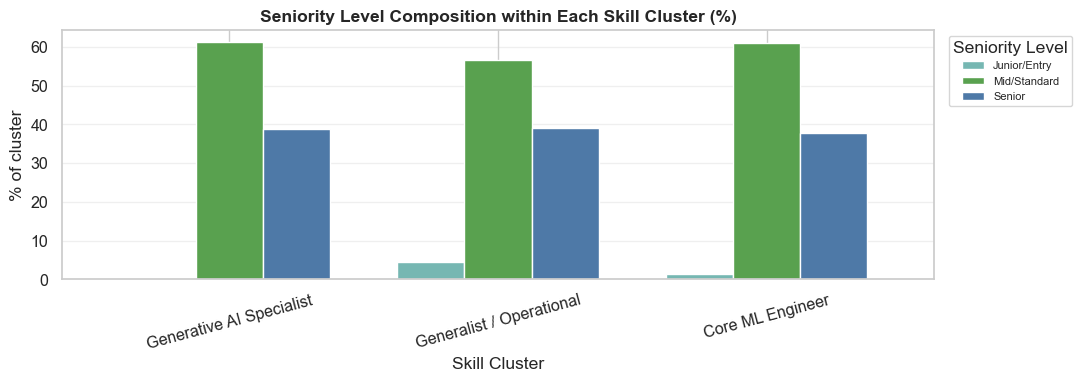

In [32]:
# ── 6a. Cross-tab: Cluster × Seniority_Level (% within cluster) ────────────────────
ct_pct = (
    pd.crosstab(df['Cluster_Name'], df['Seniority_Level'], normalize='index') * 100
).round(1).reindex(columns=EXP_ORDER, fill_value=0)

# Sort rows by cluster id
ct_pct = ct_pct.loc[[CLUSTER_NAMES[c] for c in range(K_FINAL)]]

print('Seniority Level distribution within each cluster (%):')
print(ct_pct.to_string())

fig, ax = plt.subplots(figsize=(11, 4))
ct_pct.plot(kind='bar', ax=ax, color=['#76B7B2','#59A14F','#4E79A7'],
            edgecolor='white', width=0.75)
ax.set_title('Seniority Level Composition within Each Skill Cluster (%)',
             fontweight='bold')
ax.set_xlabel('Skill Cluster')
ax.set_ylabel('% of cluster')
ax.tick_params(axis='x', rotation=15)
ax.legend(title='Seniority Level', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig5_cluster_seniority_level_bar.png', dpi=150, bbox_inches='tight')
plt.show()

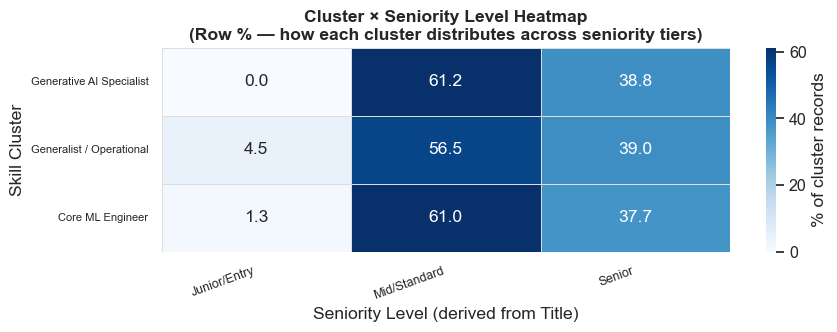

In [33]:
# ── 6b. Heatmap: Cluster × Seniority_Level ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 3.5))
sns.heatmap(
    ct_pct, ax=ax, cmap='Blues', annot=True, fmt='.1f',
    linewidths=0.5, linecolor='#dddddd',
    cbar_kws={'label': '% of cluster records'}
)
ax.set_title('Cluster × Seniority Level Heatmap\n'
             '(Row % — how each cluster distributes across seniority tiers)',
             fontweight='bold')
ax.set_xlabel('Seniority Level (derived from Title)')
ax.set_ylabel('Skill Cluster')
plt.xticks(rotation=20, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('fig6_cluster_seniority_level_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

Mean Salary by Cluster × Seniority Level:
Seniority_Level          Junior/Entry Mid/Standard    Senior
Cluster_Name                                                
Generative AI Specialist          N/A     $166,485  $172,124
Generalist / Operational      $82,676     $152,920  $174,588
Core ML Engineer              $77,536     $172,646  $198,963


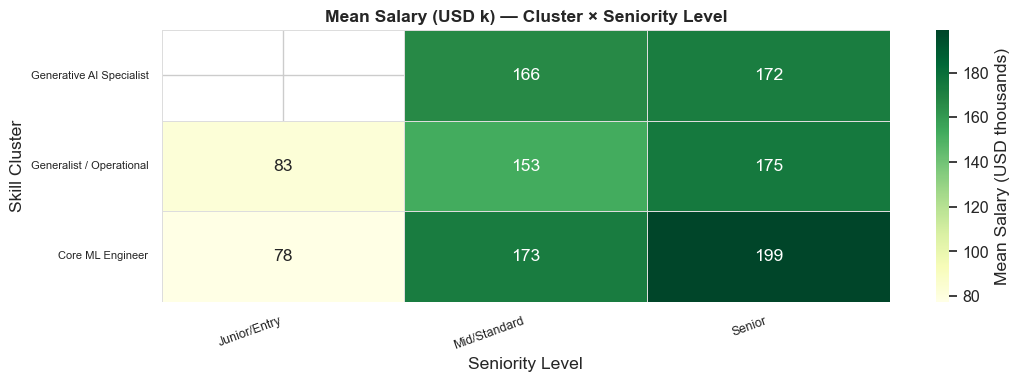

In [34]:
# ── 6c. Salary by Cluster × Seniority_Level ────────────────────────────────────────
sal_pivot = (
    df.groupby(['Cluster_Name', 'Seniority_Level'])['Salary']
    .mean()
    .unstack()
    .reindex(columns=EXP_ORDER)
    .reindex([CLUSTER_NAMES[c] for c in range(K_FINAL)])
)

print('Mean Salary by Cluster × Seniority Level:')
print(sal_pivot.applymap(lambda x: f'${x:,.0f}' if not pd.isna(x) else 'N/A').to_string())

fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(
    sal_pivot / 1000, ax=ax, cmap='YlGn', annot=True, fmt='.0f',
    linewidths=0.5, linecolor='#dddddd',
    cbar_kws={'label': 'Mean Salary (USD thousands)'}
)
ax.set_title('Mean Salary (USD k) — Cluster × Seniority Level',
             fontweight='bold')
ax.set_xlabel('Seniority Level')
ax.set_ylabel('Skill Cluster')
plt.xticks(rotation=20, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('fig7_salary_cluster_seniority_level.png', dpi=150, bbox_inches='tight')
plt.show()

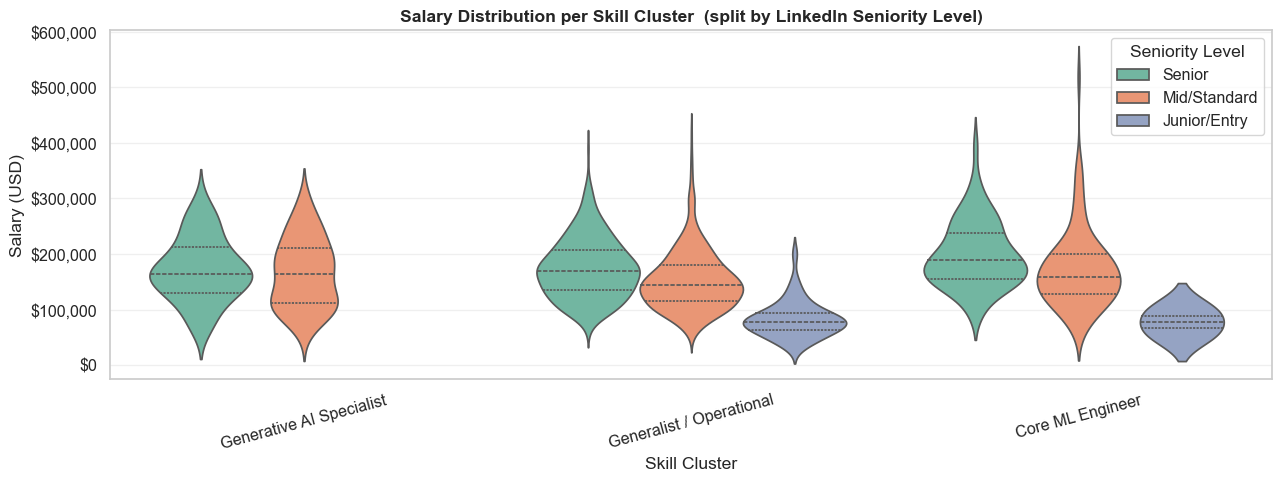

In [35]:
# ── 6d. Violin: Salary distribution per cluster, split by Seniority_Level ─────
fig, ax = plt.subplots(figsize=(13, 5))
sns.violinplot(
    data=df, x='Cluster_Name', y='Salary', hue='Seniority_Level',
    split=False, inner='quartile', palette='Set2', ax=ax,
    order=[CLUSTER_NAMES[c] for c in range(K_FINAL)]
)
ax.set_title('Salary Distribution per Skill Cluster  (split by LinkedIn Seniority Level)',
             fontweight='bold')
ax.set_xlabel('Skill Cluster')
ax.set_ylabel('Salary (USD)')
ax.tick_params(axis='x', rotation=15)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(title='Seniority Level', loc='upper right')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig8_salary_violin.png', dpi=150, bbox_inches='tight')
plt.show()

## 7 · PCA 2-D Visualisation

PC1 = 35.2%  |  PC2 = 18.7%  |  Total = 53.9%


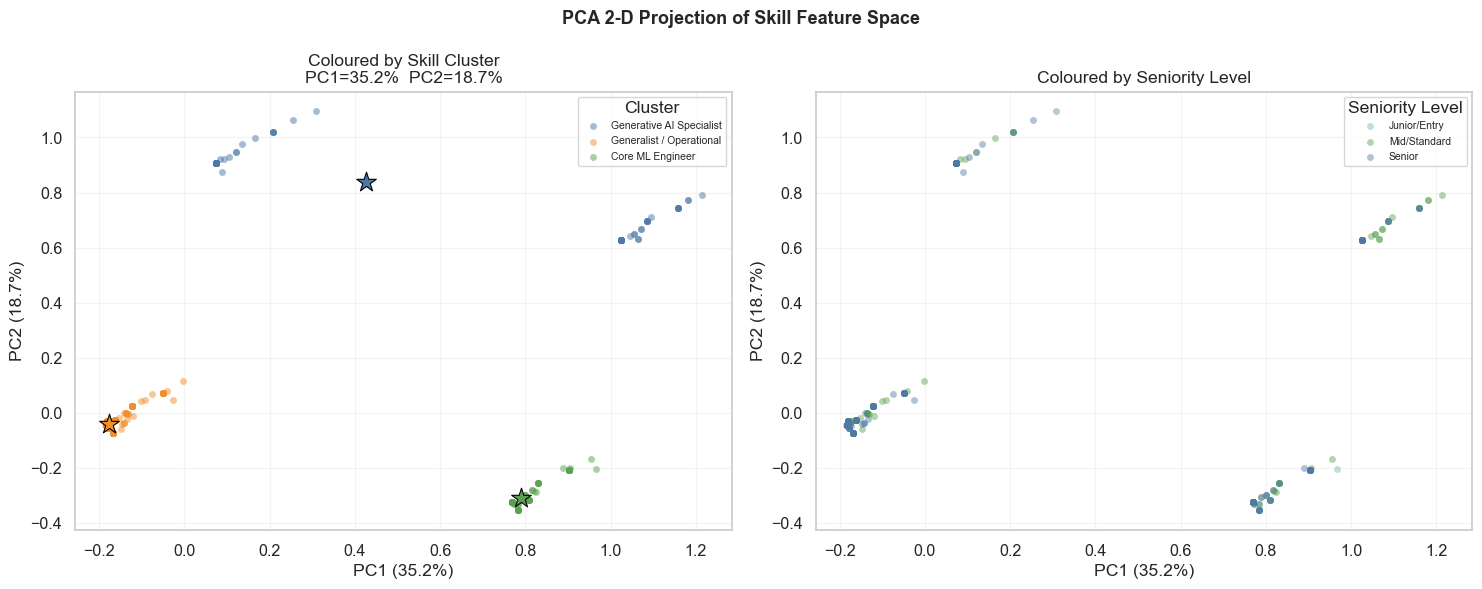

In [45]:
pca   = PCA(n_components=2, random_state=RANDOM)
X_pca = pca.fit_transform(X)
var   = pca.explained_variance_ratio_ * 100
print(f'PC1 = {var[0]:.1f}%  |  PC2 = {var[1]:.1f}%  |  Total = {var.sum():.1f}%')

pca_df = pd.DataFrame({'PC1': X_pca[:, 0], 'PC2': X_pca[:, 1],
                        'Cluster': df['Cluster'],
                        'Cluster_Name': df['Cluster_Name'],
                        'Seniority_Level': df['Seniority_Level']})

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('PCA 2-D Projection of Skill Feature Space',
             fontsize=13, fontweight='bold')

# Left: coloured by cluster
ax = axes[0]
for c in range(K_FINAL):
    sub = pca_df[pca_df['Cluster'] == c]
    ax.scatter(sub['PC1'], sub['PC2'], c=PALETTE[c],
               label=CLUSTER_NAMES[c], alpha=0.5, s=25, linewidths=0)
# Centroids
for c in range(K_FINAL):
    sub = pca_df[pca_df['Cluster'] == c]
    ax.scatter(sub['PC1'].mean(), sub['PC2'].mean(),
               c=PALETTE[c], s=220, marker='*',
               edgecolors='black', linewidths=0.8, zorder=5)
ax.set_title(f'Coloured by Skill Cluster\n'
             f'PC1={var[0]:.1f}%  PC2={var[1]:.1f}%')
ax.set_xlabel(f'PC1 ({var[0]:.1f}%)')
ax.set_ylabel(f'PC2 ({var[1]:.1f}%)')
ax.legend(fontsize=7.5, title='Cluster', loc='best')
ax.grid(True, alpha=0.2)

# Right: coloured by seniority level
ax = axes[1]
senior_palette = {'Junior/Entry':'#76B7B2','Mid/Standard':'#59A14F',
               'Senior':'#4E79A7'}
for lvl in EXP_ORDER:
    sub = pca_df[pca_df['Seniority_Level'] == lvl]
    if len(sub):
        ax.scatter(sub['PC1'], sub['PC2'], c=senior_palette[lvl],
                   label=lvl, alpha=0.45, s=25, linewidths=0)
ax.set_title('Coloured by Seniority Level')
ax.set_xlabel(f'PC1 ({var[0]:.1f}%)')
ax.set_ylabel(f'PC2 ({var[1]:.1f}%)')
ax.legend(fontsize=7.5, title='Seniority Level', loc='best')
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('fig9_pca_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## 8 · Skill Co-occurrence Bubble Chart

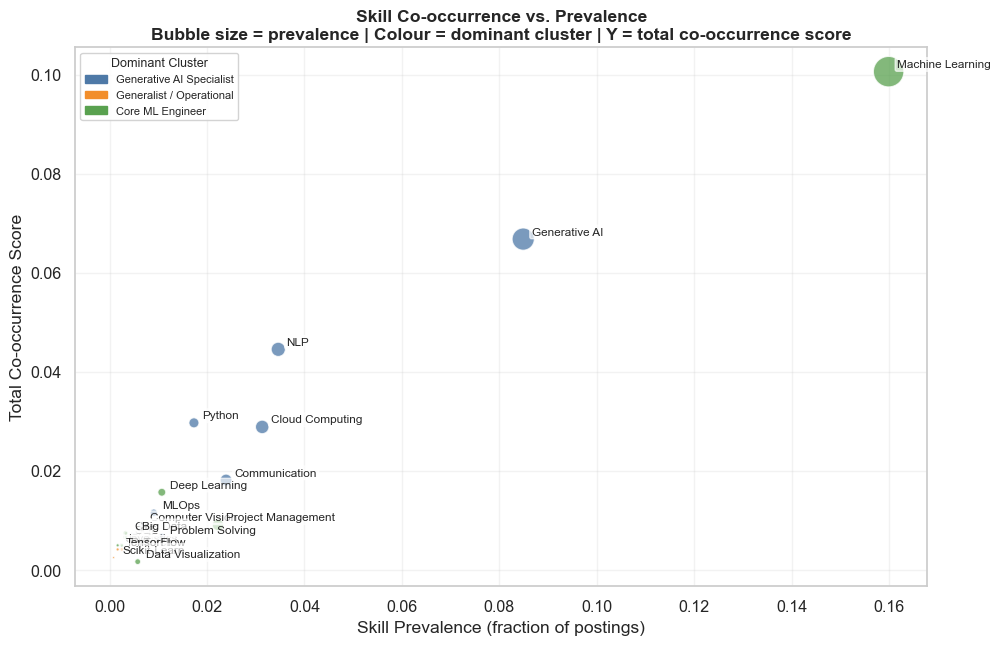

<Figure size 1000x600 with 0 Axes>

In [48]:
# Skills with any signal (prevalence > 0)
active_mask  = X.mean(axis=0) > 0
active_skills = [s for s, m in zip(SKILL_COLS, active_mask) if m]
X_active      = X[:, active_mask]

co_matrix = (X_active.T @ X_active) / len(X_active)   # joint probability
np.fill_diagonal(co_matrix, 0)

prevalence   = X_active.mean(axis=0)
co_sum       = co_matrix.sum(axis=1)
dom_cluster  = np.argmax(centroids[:, active_mask], axis=0)

fig, ax = plt.subplots(figsize=(11, 7))
scatter = ax.scatter(
    prevalence, co_sum,
    s=prevalence * 3000,
    c=[PALETTE[d % len(PALETTE)] for d in dom_cluster],
    alpha=0.75, edgecolors='white', linewidths=0.8
)
for i, name in enumerate(active_skills):
    ax.annotate(name, (prevalence[i], co_sum[i]),
                textcoords='offset points', xytext=(6, 3), fontsize=8.5,
                bbox=dict(boxstyle='round,pad=0.15', fc='white', alpha=0.65))

legend_handles = [
    mpatches.Patch(color=PALETTE[c], label=CLUSTER_NAMES[c])
    for c in range(K_FINAL)
]
ax.legend(handles=legend_handles, title='Dominant Cluster', fontsize=8,
          title_fontsize=9, loc='upper left', framealpha=0.85)
ax.set_title('Skill Co-occurrence vs. Prevalence\n'
             'Bubble size = prevalence | Colour = dominant cluster | '
             'Y = total co-occurrence score',
             fontweight='bold')
ax.set_xlabel('Skill Prevalence (fraction of postings)')
ax.set_ylabel('Total Co-occurrence Score')
ax.grid(True, alpha=0.25)
plt.figure(figsize=(10, 6))
plt.tight_layout()
plt.savefig('fig10_cooccurrence_bubble.png', dpi=150, bbox_inches='tight')
plt.show()

## 9 · Comprehensive Cluster Profiles Summary

In [49]:
profile_rows = []

for c in range(K_FINAL):
    mask   = df['Cluster'] == c
    subset = df[mask]
    n      = int(mask.sum())

    top_idx    = np.argsort(centroids[c])[::-1][:5]
    top_skills = [SKILL_COLS[i] for i in top_idx if centroids[c][i] > 0]
    top_vals   = [round(centroids[c][i], 3) for i in top_idx if centroids[c][i] > 0]

    print(f"\n{'='*65}")
    print(f"Cluster {c}: {CLUSTER_NAMES[c]}  (n={n:,}, {n/len(df)*100:.1f}%)")
    print(f"{'='*65}")
    print(f"  Top skills     : {list(zip(top_skills, top_vals))}")
    print(f"  Avg salary     : ${subset['Salary'].mean():,.0f}")
    print(f"  Salary range   : ${subset['Salary'].min():,.0f} – ${subset['Salary'].max():,.0f}")
    print(f"  Top Field      : {subset['Field'].value_counts().index[0]} "
          f"({subset['Field'].value_counts().iloc[0]/n*100:.0f}%)")
    print(f"  Seniority breakdown:")
    senior_dist = (subset['Seniority_Level'].value_counts() / n * 100).round(1)
    for lvl in EXP_ORDER:
        pct = senior_dist.get(lvl, 0.0)
        bar = '█' * int(pct / 2)
        print(f"    {lvl:<18s}: {pct:5.1f}%  {bar}")

    for rank, (skill, val) in enumerate(zip(top_skills, top_vals), 1):
        profile_rows.append({
            'cluster_id'     : c,
            'cluster_name'   : CLUSTER_NAMES[c],
            'n_records'      : n,
            'pct_of_total'   : round(n / len(df) * 100, 1),
            'skill_rank'     : rank,
            'skill'          : skill,
            'centroid_value' : val,
            'mean_salary'    : round(subset['Salary'].mean(), 2),
            'top_field'      : subset['Field'].value_counts().index[0],
        })


Cluster 0: Generative AI Specialist  (n=103, 8.5%)
  Top skills     : [('Generative AI', np.float64(1.0)), ('Machine Learning', np.float64(0.34)), ('NLP', np.float64(0.136)), ('Cloud Computing', np.float64(0.087)), ('Python', np.float64(0.058))]
  Avg salary     : $168,675
  Salary range   : $61,662 – $299,825
  Top Field      : IT (88%)
  Seniority breakdown:
    Junior/Entry      :   0.0%  
    Mid/Standard      :  61.2%  ██████████████████████████████
    Senior            :  38.8%  ███████████████████

Cluster 1: Generalist / Operational  (n=951, 78.4%)
  Top skills     : [('Cloud Computing', np.float64(0.023)), ('Communication', np.float64(0.022)), ('Project Management', np.float64(0.02)), ('NLP', np.float64(0.015)), ('Problem Solving', np.float64(0.012))]
  Avg salary     : $158,197
  Salary range   : $33,046 – $422,081
  Top Field      : IT (78%)
  Seniority breakdown:
    Junior/Entry      :   4.5%  ██
    Mid/Standard      :  56.5%  ████████████████████████████
    Senior    

## 10 · Export Results to CSV

In [ ]:
# ── Full labelled dataset ─────────────────────────────────────────────────────
output_cols = META_COLS + SKILL_COLS + ['Exp_Level', 'Cluster', 'Cluster_Name']
df[output_cols].to_csv('results_labelled_postings.csv', index=False)
print(f'Saved → results_labelled_postings.csv  ({len(df):,} rows)')

# ── Cluster profiles ──────────────────────────────────────────────────────────
pd.DataFrame(profile_rows).to_csv('results_cluster_profiles.csv', index=False)
print('Saved → results_cluster_profiles.csv')

# ── Cluster × Exp_Level cross-tab ─────────────────────────────────────────────
ct_pct.reset_index().rename(columns={'index': 'Cluster_Name'}) \
       .to_csv('results_cluster_explevel_pct.csv', index=False)
print('Saved → results_cluster_explevel_pct.csv')

# ── Salary pivot ──────────────────────────────────────────────────────────────
sal_pivot.round(2).to_csv('results_salary_pivot.csv')
print('Saved → results_salary_pivot.csv')

# ── Centroid matrix ───────────────────────────────────────────────────────────
centroid_out = pd.DataFrame(centroids, columns=SKILL_COLS)
centroid_out.insert(0, 'cluster_id', range(K_FINAL))
centroid_out.insert(1, 'cluster_name', [CLUSTER_NAMES[c] for c in range(K_FINAL)])
centroid_out.to_csv('results_centroids.csv', index=False)
print('Saved → results_centroids.csv')

# ── K-search scores ───────────────────────────────────────────────────────────
# already saved earlier as cluster_k_search.csv

# ── PCA coords ───────────────────────────────────────────────────────────────
pca_df['PC1_var'] = round(var[0], 2)
pca_df['PC2_var'] = round(var[1], 2)
pca_df.to_csv('results_pca_coords.csv', index=False)
print('Saved → results_pca_coords.csv')

print('\n✓ All outputs saved.')